In [1]:
from pathlib import Path
import sys
import os.path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from scipy.stats import f_oneway, gaussian_kde, mannwhitneyu, pearsonr, spearmanr
import seaborn as sns
import matplotlib.lines as mlines
import logging

from tqdm.notebook import tqdm
from pymodulon.compare import compare_ica
from pymodulon.core import IcaData
from pymodulon.io import load_json_model, save_to_json
from pymodulon.plotting import *

from pymodulon.util import explained_variance
from pymodulon.imodulondb import imdb_gene_presence
sns.set_style('whitegrid')
pd.set_option('display.max_rows', 500)

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.sans-serif'] = 'Arial'
matplotlib.rcParams['font.family'] = 'sans-serif'
sns.set_style('ticks')
matplotlib.rcParams['text.color'] = '#000000'
matplotlib.rcParams['axes.labelcolor'] = '#000000'
matplotlib.rcParams['xtick.color'] = '#000000'
matplotlib.rcParams['ytick.color'] = '#000000'

In [3]:
ica_data = load_json_model('C:\\Users\\99hee\\precise_mg1655_R1\\data\\p_mg1655\\PRECISE_WT_MG1655_final2.json.gz')

## Figure 2A

In [4]:
ica_data.imodulon_table.enrichment_category.value_counts()

regulatory         77
technical          23
uncharacterized     9
biological          6
Name: enrichment_category, dtype: int64

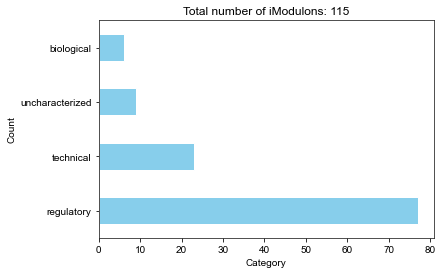

In [5]:
counts = ica_data.imodulon_table.enrichment_category.value_counts()

counts.plot(kind='barh', color='skyblue')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Total number of iModulons: 115')
plt.show()

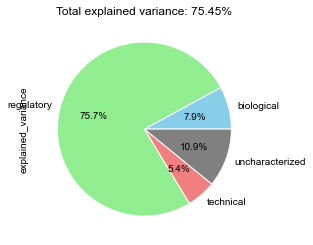

In [6]:
counts = ica_data.imodulon_table.groupby('enrichment_category').sum('explained_variance').explained_variance

counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen', 'lightcoral', 'grey'])
plt.title('Total explained variance: 75.45%')
plt.show()

## Figure 2B

In [7]:
def compare_imodulons_vs_regulons(
    ica_data,
    imodulons=None,
    cat_column=None,
    size_column=None,
    scale=1,
    reg_only=True,
    xlabel=None,
    ylabel=None,
    vline=0.6,
    hline=0.6,
    ax=None,
    scatter_kwargs=None,
    ax_font_kwargs=None,
    legend_kwargs=None,
    legend_marker_size=100,
):
    """
    Compare the overlaps between iModulons and their linked regulons

    Parameters
    ----------
    ica_data: ~pymodulon.core.IcaData
        :class:`~pymodulon.core.IcaData` object
    imodulons: list, optional
        List of iModulons to plot
    cat_column: str, optional
        Column in the `imodulon_table` that stores the category of each iModulon
    size_column: str, optional
        Column in the `imodulon_table` that stores the size of each iModulon
    scale: float, optional (default: 1)
        Value used to scale the size of each point
    reg_only: bool (default: True)
        Only plot iModulons with an entry in the `regulator` column of the
        `imodulon_table`
    xlabel: str, optional
        Custom x-axis label (default: "# shared genes/Regulon size")
    ylabel: str, optional
        Custom y-axis label (default: "# shared genes/iModulon size")
    vline: float, optional (default: 0.6)
        Draw a dashed vertical line
    hline: float, optional (default: 0.6)
        Draw a dashed horizontal line
    ax: ~matplotlib.axes.Axes, optional
        Axes object to plot on, otherwise use current Axes
    scatter_kwargs: dict, optional
        Additional keyword arguments passed to :func:`matplotlib.pyplot.scatter`
    ax_font_kwargs: dict, optional
        Additional keyword arguments for axes labels
    legend_kwargs: dict, optional
        Additional keyword arguments passed to :func:`matplotlib.pyplot.legend`
    legend_marker_size: int, optional (default: 100)
        Size of the legend markers (area units, to match scatter plot s parameter)

    Returns
    -------
    ax: ~matplotlib.axes.Axes
        :class:`~matplotlib.axes.Axes` containing the line plot
    """

    # Set up axis
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    # Handle kwargs
    if scatter_kwargs is None:
        scatter_kwargs = {}
    if ax_font_kwargs is None:
        ax_font_kwargs = {}
    if legend_kwargs is None:
        legend_kwargs = {}

    # Set axes labels
    if xlabel is None:
        xlabel = "$\\frac{\\mathrm{\\#\\;Shared\\;Genes}}{\\mathrm{Regulon\\;Size}}$"
        xlabelscale = 2
    else:
        xlabelscale = 1

    if ylabel is None:
        ylabel = "$\\frac{\\mathrm{\\#\\;Shared\\;Genes}}{\\mathrm{iModulon\\;Size}}$"
        ylabelscale = 2
    else:
        ylabelscale = 1

    # Select iModulons
    if imodulons is None:
        reg_table = ica_data.imodulon_table.copy()
        if reg_only:
            reg_table = reg_table[reg_table.regulator.notnull()]
    else:
        reg_table = ica_data.imodulon_table.loc[imodulons]

    # Select category column
    if cat_column is None:
        reg_table["_category"] = "iModulons"
        cat_column = "_category"

    # Make sure all necessary columns exist
    if reg_table.recall.isnull().any():
        logging.warning(
            "Some iModulons have missing `recall` entries in the "
            "`imodulon_table` and will not be shown"
        )
    if reg_table.precision.isnull().any():
        logging.warning(
            "Some iModulons have missing `precision` entries in the "
            "`imodulon_table` and will not be shown"
        )
    if size_column is not None and reg_table[size_column].isnull().any():
        logging.warning(
            f"Some iModulons have missing {size_column} entries in the "
            "`imodulon_table`"
        )

    # Create a color map for categories
    unique_categories = reg_table[cat_column].unique()
    cmap = plt.get_cmap('tab20')  # colormap with enough distinct colors
    group_color_mapping = {cat: cmap(i % cmap.N) for i, cat in enumerate(unique_categories)}

    # Plot each category group
    for cat, group in reg_table.groupby(cat_column):

        # Set point sizes
        if size_column is None:
            # Default marker size (scatter's 's' is area in points^2)
            default_s = scatter_kwargs.get("s", plt.rcParams["lines.markersize"] ** 2)
            size_ivr = default_s
        else:
            size_ivr = scatter_kwargs.get("s", group[size_column] * scale)

        edgecolor_ivr = scatter_kwargs.get("edgecolor", "k")

        ax.scatter(
            group.recall,
            group.precision,
            s=size_ivr * scale if size_column is not None else size_ivr,
            edgecolor=edgecolor_ivr,
            label=cat,
            color=group_color_mapping[cat],
            **{k:v for k,v in scatter_kwargs.items() if k not in ['s', 'edgecolor']}
        )

    # Set plot boundaries
    xmin, xmax = ax.get_xlim()
    xmin = min(xmin, 0)
    xmax = max(xmax, 1)
    ax.set_xlim((xmin, xmax))

    ymin, ymax = ax.get_ylim()
    ymin = min(ymin, 0)
    ymax = max(ymax, 1)
    ax.set_ylim((ymin, ymax))

    # Add dashed lines
    if hline:
        ax.hlines(hline, xmin, xmax, linestyles="dashed", colors="gray", zorder=0)
    if vline:
        ax.vlines(vline, ymin, ymax, linestyles="dashed", colors="gray", zorder=0)

    # Set axis labels
    label_size = ax_font_kwargs.pop("fontsize", plt.rcParams["font.size"])
    xlabel_size = label_size * xlabelscale
    ax.set_xlabel(xlabel, fontsize=xlabel_size, **ax_font_kwargs)

    ylabel_size = label_size * ylabelscale
    ax.set_ylabel(ylabel, fontsize=ylabel_size, **ax_font_kwargs)

    handles = []
    for cat in unique_categories:
        handles.append(
            mlines.Line2D(
                [], [],
                color=group_color_mapping[cat],
                marker='o',
                linestyle='None',
                markersize=(legend_marker_size ** 0.6) / 2,
                markeredgecolor='k'
            )
        )

    labels = list(map(str, unique_categories))

    bbox_to_anchor_ivr = legend_kwargs.pop("bbox_to_anchor", (1, 1))
    ax.legend(handles=handles, labels=labels, bbox_to_anchor=bbox_to_anchor_ivr, **legend_kwargs)

    return ax

<AxesSubplot: xlabel='$\\frac{\\mathrm{\\#\\;Shared\\;Genes}}{\\mathrm{Regulon\\;Size}}$', ylabel='$\\frac{\\mathrm{\\#\\;Shared\\;Genes}}{\\mathrm{iModulon\\;Size}}$'>

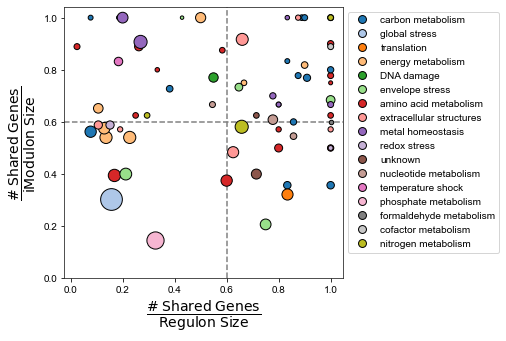

In [8]:
compare_imodulons_vs_regulons(ica_data,
                              size_column='imodulon_size',
                              cat_column='functional_category',
                              scale=2)

## Figure 2C
code provided in expression fig__investigate_expression.ipynb notebook

## Figure 2D

In [9]:
ica_data.imodulon_table.loc[['RpoS', 'Phosphate','LPS','Fur-1','Osmoprotectant']].imodulon_size

RpoS              118
Phosphate          74
LPS                62
Fur-1              43
Osmoprotectant      3
Name: imodulon_size, dtype: int64

In [10]:
ica_data.imodulon_table['imodulon_size'].median()

9.0

Text(0, 0.5, '# of iMs')

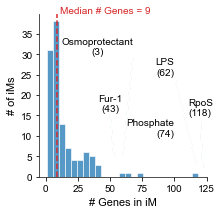

In [11]:
_, ax = plt.subplots(figsize=(3, 3))

sns.histplot(ica_data.imodulon_table['imodulon_size'], bins=25, ax=ax)

for s_loc, s in ax.spines.items():
    if s_loc in ['top', 'right']:
        s.set_visible(False)

med_size = ica_data.imodulon_table['imodulon_size'].median()
ax.axvline(med_size, linestyle='--', color='tab:red')
ax.text(med_size + 2, 40, f'Median # Genes = {int(med_size)}', color='tab:red')
        
ax.annotate('RpoS\n(118)', xy=(122, 2), xytext=(120, 15), arrowprops={'headwidth': 0, 'width': 1, 'headlength': 0.1}, ha='center')
ax.annotate('LPS\n(62)', xy=(117, 3), xytext=(100, 25), arrowprops={'headwidth': 0, 'width': 1, 'headlength': 0.1}, ha='right')
ax.annotate('Phosphate\n(74)', xy=(100, 3), xytext=(100, 10), arrowprops={'headwidth': 0, 'width': 1, 'headlength': 0.1}, ha='right')
ax.annotate('Fur-1\n(43)', xy=(53, 5), xytext=(50, 16), arrowprops={'headwidth': 0, 'width': 1, 'headlength': 0.1}, ha='center')
ax.annotate('Osmoprotectant\n(3)', xy=(60, 5), xytext=(40, 30), arrowprops={'headwidth': 0, 'width': 1, 'headlength': 0.1}, ha='center')


ax.set_xticks(range(0, 150, 25))
ax.set_xlabel('# Genes in iM', fontsize=11)
ax.set_ylabel('# of iMs', fontsize=11)

## Figure 2E

In [12]:
gene_im_df = pd.DataFrame(ica_data.M_binarized.sum(axis=1).sort_values(ascending=False), columns=['n_ims']).merge(
    ica_data.gene_table, how='left', left_index=True, right_index=True)

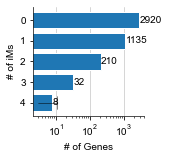

In [13]:
_, ax = plt.subplots(figsize=(2, 2))

plot_dict = {int(n_ims): n_im_df.shape[0] for n_ims, n_im_df in gene_im_df.groupby('n_ims')}

for n_ims, gene_count in plot_dict.items():
    ax.barh(len(plot_dict) - n_ims, gene_count, color='tab:blue')
    ax.text(gene_count * 1.02, len(plot_dict) - n_ims, gene_count, va='center')

for loc, s in ax.spines.items():
    if loc in ['top', 'right']:
        s.set_visible(False)
ax.set_yticks(range(1, 6))
ax.set_yticklabels(list(range(0, 5))[::-1])
ax.set_xscale('log')
ax.xaxis.grid()

ax.set_xlabel('# of Genes', fontsize=10)
ax.set_ylabel('# of iMs', fontsize=10)

ax.plot((3, 11), (1, 1), linewidth=0.5, color='k')
ax.plot((11, 11), (0.7, 1.3), linewidth=0.5, color='k')

## Figure 2F

In [14]:
# gene order: order genes by number of iMs that gene belongs to
gene_order = ica_data.M_binarized.sum(axis=1).sort_values(ascending=False).index
# order based on iM size
im_order = ica_data.M_binarized.sum(axis=0).sort_values(ascending=False).index

M_sorted = ica_data.M.loc[gene_order][im_order]
M_binarized_sorted = ica_data.M_binarized.loc[gene_order][im_order]

C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


10.16% of entries in top 80 genes/40 iMs


Text(16.0, 0.5, '')

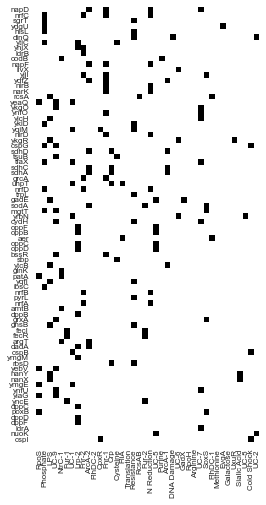

In [15]:
sns.heatmap(M_binarized_sorted, xticklabels=False, yticklabels=False, cbar=False, cmap=['white', 'black'], ax=ax)

display_n_genes = 80
display_n_ims = 40

gene_zoom_frac = 1 - display_n_genes / M_binarized_sorted.shape[0]
imod_zoom_frac = display_n_ims / M_binarized_sorted.shape[1]

ax.plot((0, imod_zoom_frac), (gene_zoom_frac, gene_zoom_frac), transform=ax.transAxes, color='tab:red', linewidth=1)
ax.plot((imod_zoom_frac, imod_zoom_frac), (gene_zoom_frac, 1), transform=ax.transAxes, color='tab:red', linewidth=1)

total_ones = M_binarized_sorted.sum().sum()
display_slice = M_binarized_sorted.iloc[:display_n_genes, :display_n_ims]
display_slice.index = ica_data.gene_table.loc[display_slice.index]['gene_name']
display_ones = display_slice.sum().sum()

print(f'{display_ones/total_ones*100:.2f}% of entries in top {display_n_genes} genes/{display_n_ims} iMs')

for s in ax.spines.values():
    s.set_visible(True)

ax.set_xlabel('115 iModulons', fontsize=12)
ax.set_ylabel('4305 genes', fontsize=12)

sns.set_style('whitegrid')

_, ax = plt.subplots(figsize=(4, 8))

sns.heatmap(display_slice, xticklabels=True, yticklabels=True, cbar=False, cmap=['white', 'black'], linewidths=0.003, linecolor='k', ax=ax)

ax.tick_params(axis='both', labelsize=8)
ax.set_ylabel('')